In [1]:
import zipfile
import os

# Define paths
zip_path = "datasetfire.zip"  # Update this if the path is different
extract_to = "firedataset"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted successfully to:", extract_to)

Dataset extracted successfully to: firedataset


In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 1.3 MB/s eta 0:00:31
    --------------------------------------- 0.8/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.0/39.5 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.3/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.6/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.8/39.5 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.1/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.4/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.6/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.9/39.5 MB 1.2 MB/s eta 0:00:30
   --- ------------------------------------ 3.1/39.5 MB 1.2 MB/s eta 0:00:30
   --- ------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 1.3 MB/s eta 0:00:31
    --------------------------------------- 0.8/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.0/39.5 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.3/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.6/39.5 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.8/39.5 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.1/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.4/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.6/39.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.9/39.5 MB 1.2 MB/s eta 0:00:30
   --- ------------------------------------ 3.1/39.5 MB 1.2 MB/s eta 0:00:30
   --- ------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


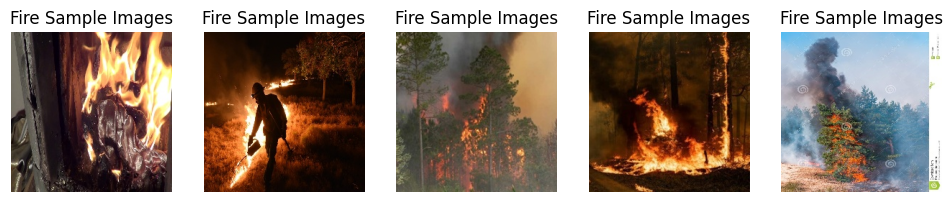

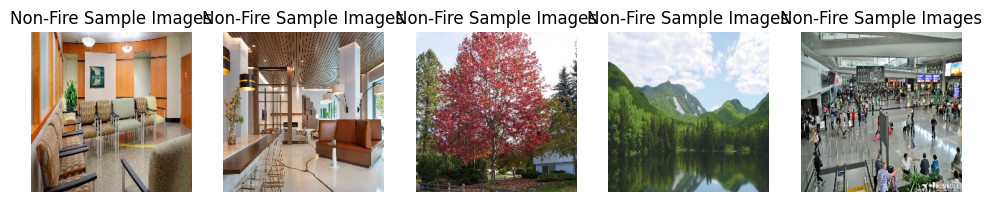

In [4]:
import os
import matplotlib.pyplot as plt
import cv2
import random

# Define dataset path
dataset_path = "firedataset/FireDataset-V6-JPG-Reshaped224"

# Define train and test paths
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

# Define fire and non-fire paths
fire_train_path = os.path.join(train_path, "fire")
non_fire_train_path = os.path.join(train_path, "non_fire")

fire_test_path = os.path.join(test_path, "fire")
non_fire_test_path = os.path.join(test_path, "non_fire")

# Function to display random images from a folder
def display_images(folder_path, title, num_images=5):
    image_files = os.listdir(folder_path)
    selected_images = random.sample(image_files, min(num_images, len(image_files)))
    
    plt.figure(figsize=(12, 6))
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
    
    plt.show()

# Display sample images
display_images(fire_train_path, "Fire Sample Images")
display_images(non_fire_train_path, "Non-Fire Sample Images")

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.models import efficientnet_b0
import os
from PIL import Image

In [6]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # EfficientNet normalization
])

In [7]:
# Define dataset paths
train_dir = "firedataset/FireDataset-V6-JPG-Reshaped224/train"
test_dir = "firedataset/FireDataset-V6-JPG-Reshaped224/test"

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# Handle class imbalance using sampling weights
class_counts = [0, 0]  # [Non-Fire, Fire]
for _, label in train_dataset:
    class_counts[label] += 1

# Compute class weights
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for _, label in train_dataset]

# Use WeightedRandomSampler for balanced batches
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader

# Load EfficientNet-B0 with correct weights
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Modify classifier for binary classification (Fire vs. Non-Fire)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)  # 2 output classes

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Define Data Transforms
transform = transforms.Compose([
    transforms.Resize((96, 96)),  # Reduce image size for efficiency
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# **Fix: Use GradScaler only if CUDA is available**
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None  # Fixed warning

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Tanmay Verma/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:18<00:00, 1.16MB/s]


In [9]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Define dataset paths
train_dir = "firedataset/FireDataset-V6-JPG-Reshaped224/train"
test_dir = "firedataset/FireDataset-V6-JPG-Reshaped224/test"

# Load datasets with transformations
train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

# **Optimized DataLoader settings**
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# **Training Loop**
num_epochs = 5  # Adjust based on performance
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # **Use mixed precision training if CUDA is available**
        with torch.amp.autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Scale loss only if using mixed precision
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training Complete! ")

Epoch [1/5], Loss: 0.1595
Epoch [2/5], Loss: 0.0447
Epoch [3/5], Loss: 0.0210
Epoch [4/5], Loss: 0.0113
Epoch [5/5], Loss: 0.0166
Training Complete! 


In [10]:
from sklearn.metrics import accuracy_score, classification_report
import torch.nn.functional as F

# Switch to evaluation mode
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():  # Disable gradient calculation
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=1)  # Get class with highest probability

        all_preds.extend(preds.cpu().numpy())  # Store predictions
        all_labels.extend(labels.cpu().numpy())  # Store true labels

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display detailed classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Test Accuracy: 97.90%
Classification Report:
              precision    recall  f1-score   support

        fire       0.99      0.97      0.98       244
    non_fire       0.97      0.99      0.98       280

    accuracy                           0.98       524
   macro avg       0.98      0.98      0.98       524
weighted avg       0.98      0.98      0.98       524



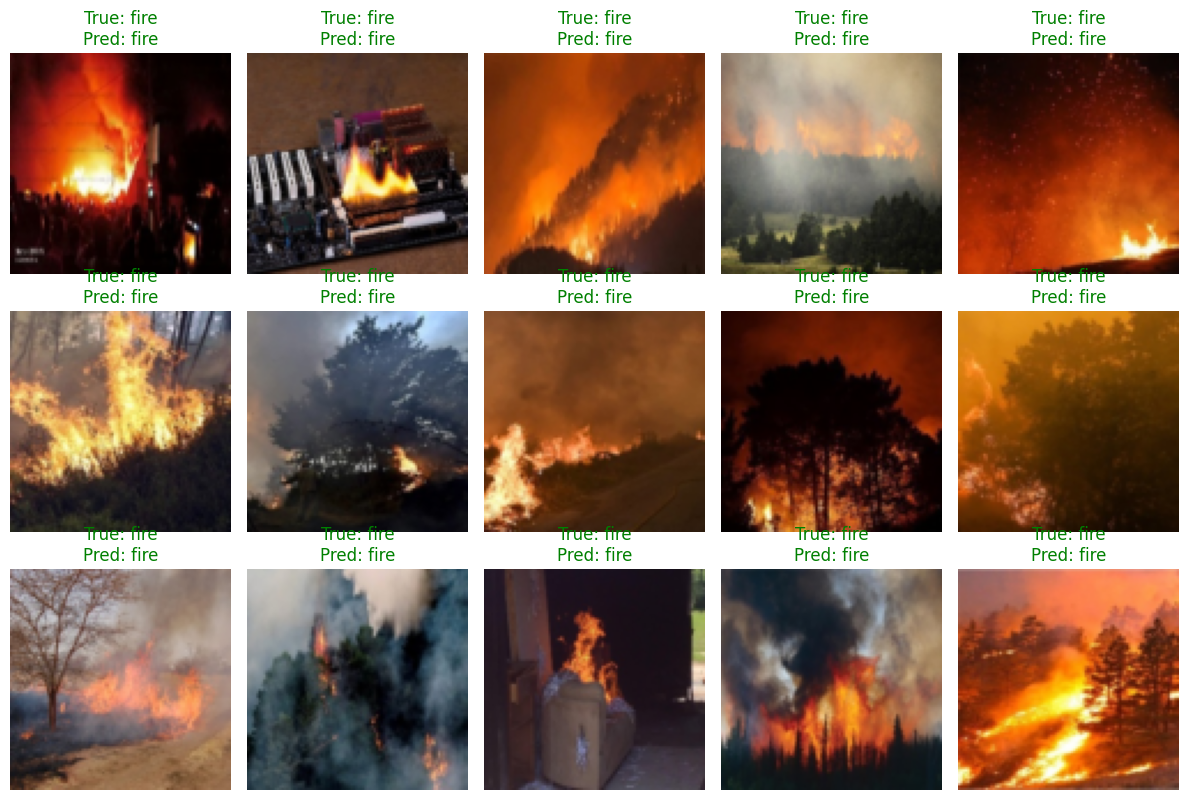

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test images
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Move images to the correct device
images, labels = images.to(device), labels.to(device)

# Get model predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)  # Convert logits to probabilities
    preds = torch.argmax(probs, dim=1)  # Get predicted labels

# **Plot the images with their predicted labels**
fig, axes = plt.subplots(3, 5, figsize=(12, 8))  # Display 15 images
axes = axes.flatten()

for idx in range(15):  # Display first 15 images
    img = images[idx].cpu().numpy().transpose((1, 2, 0))  # Convert tensor to NumPy image
    img = (img * 0.5) + 0.5  # Unnormalize

    label = train_dataset.classes[labels[idx].cpu().item()]  # True label
    pred = train_dataset.classes[preds[idx].cpu().item()]  # Predicted label

    axes[idx].imshow(img)
    axes[idx].axis("off")
    axes[idx].set_title(f"True: {label}\nPred: {pred}", color="green" if label == pred else "red")

plt.tight_layout()
plt.show()

In [12]:
import torch

# Save the trained model
model_path = "fire_detection_model.pth"
torch.save(model.state_dict(), model_path)

print(f"Model saved at {model_path}")

Model saved at fire_detection_model.pth


In [13]:
pip install streamlit


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install flask torch torchvision pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0 with correct weights
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Modify classifier for binary classification (Fire vs. Non-Fire)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)  # 2 output classes

# Move model to device
model = model.to(device)

# Define optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Define Data Transforms
transform = transforms.Compose([
    transforms.Resize((96, 96)),  # Reduce image size for efficiency
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Use GradScaler only if CUDA is available (Automatic Mixed Precision for better performance)
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None

# Print model summary (optional, for debugging)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [16]:
with open("app124.py", "w") as f:
    f.write("""
from flask import Flask, request, jsonify
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import io

app = Flask(__name__)

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load("fire_detection_model.pth", map_location=device))
model.to(device)
model.eval()

# Define the image transformations
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400

    file = request.files['file']
    image = Image.open(io.BytesIO(file.read())).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probabilities = torch.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)

    class_names = ["Non-Fire", "Fire"]
    result = class_names[predicted.item()]
    confidence = probabilities[0][predicted.item()].item()

    return jsonify({'prediction': result, 'confidence': confidence})

if __name__ == '__main__':
    app.run(debug=True)
    """)